##Capstone A1 (College STEM Outcome Analyzer)

In [ ]:
# Load from your downloaded copy of nvb_college_stem_outcomes.csv
# replace ID with 15NZhY30mK1ysQhTWatWv87oahSfOtq9y
# When ready, hit run
import pandas as pd
import matplotlib.pyplot as plt
url = 'https://drive.google.com/uc?id=[ID]'
df = pd.read_csv(url)
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 300 rows, 12 columns


In [ ]:
# Inspection (first 10 columns)
"""Inspect data after loading"""
print(f"Shape: {df.shape}")
print()
print("First 10 columns:")
print(df.dtypes)
print()
print("Row types:")
print(df.head(10))
print()
print("Basic statistics:")
print(df.describe().round(2))

Shape: (300, 12)

First 10 columns:
student_id               object
university               object
major                    object
year                     object
credits_completed       float64
cumulative_gpa          float64
internship_completed      int64
research_experience       int64
clubs_count               int64
scholarship               int64
employment_status        object
graduated_on_time       float64
dtype: object

Row types:
  student_id                  university                   major       year  \
0       C001  Tennessee State University    Chemical Engineering     Senior   
1       C002             Spelman College  Electrical Engineering     Junior   
2       C003             Spelman College   Aerospace Engineering     Senior   
3       C004            Prairie View A&M   Aerospace Engineering   Freshman   
4       C005               Virginia Tech    Chemical Engineering  Sophomore   
5       C006            Prairie View A&M  Biomedical Engineering     Senior   
6

Do students with higher GPAs involve themselves in more clubs?

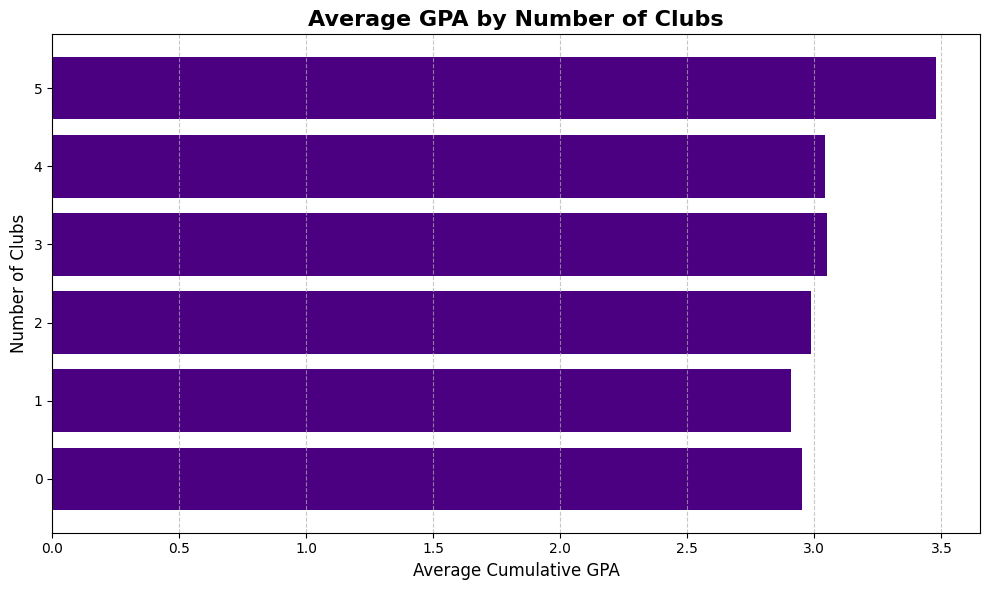

Finding: This horizontal bar chart shows the average cumulative GPA for students involved in a specific number of clubs. 
It appears that students in more clubs generally have higher GPAs (excluding those in no clubs).


In [76]:
"""Calculate what GPA values correspond to how many clubs"""
avg_gpa_by_clubs = df.groupby('clubs_count')['cumulative_gpa'].mean().sort_index()

plt.figure(figsize=(10, 6))
plt.barh(avg_gpa_by_clubs.index, avg_gpa_by_clubs.values, color='indigo')

plt.title("Average GPA by Number of Clubs", fontsize=16, fontweight="bold")
plt.xlabel("Average Cumulative GPA", fontsize=12)
plt.ylabel("Number of Clubs", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Finding: This horizontal bar chart shows the average cumulative GPA for students involved in a specific number of clubs. \nIt appears that students in more clubs generally have higher GPAs (excluding those in no clubs).")

Does having any research experience correlate employment and/or enrollment in graduate school?

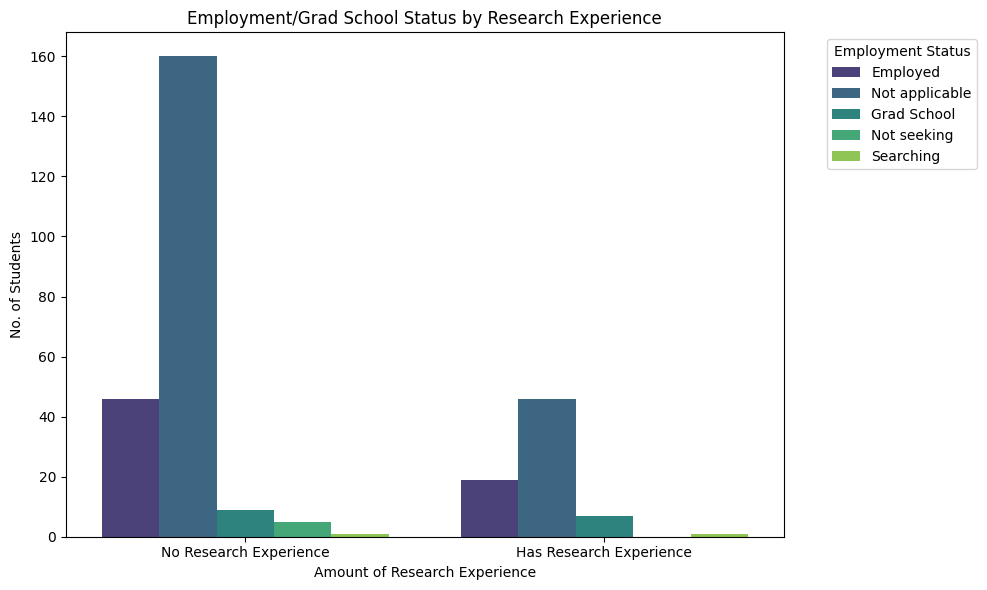

Finding: The data between research and non-research students are scaled, the distribution of students in any of the 5 positions is not affected by research experience, as both sets of bars show a visual pattern. 
The only difference between the two in amounts of research experience is the total number of students that fall into these two categories.


In [71]:
"""Calculate future prospects correlation between research and non-research students"""
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='research_experience', hue='employment_status', palette='viridis') # Cool color scheming
plt.title('Employment/Grad School Status by Research Experience')
plt.xlabel('Amount of Research Experience')
plt.ylabel('No. of Students')
plt.xticks(ticks=[0, 1], labels=['No Research Experience', 'Has Research Experience'])
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left') # Places a legend box, showing employment status based on color for the five groups of students
plt.tight_layout()
plt.show()
print("Finding: The data between research and non-research students are scaled, the distribution of students in any of the 5 positions is not affected by research experience, as both sets of bars show a visual pattern. \nThe only difference between the two in amounts of research experience is the total number of students that fall into these two categories.")


Lastly, let's compare students' major and their GPA

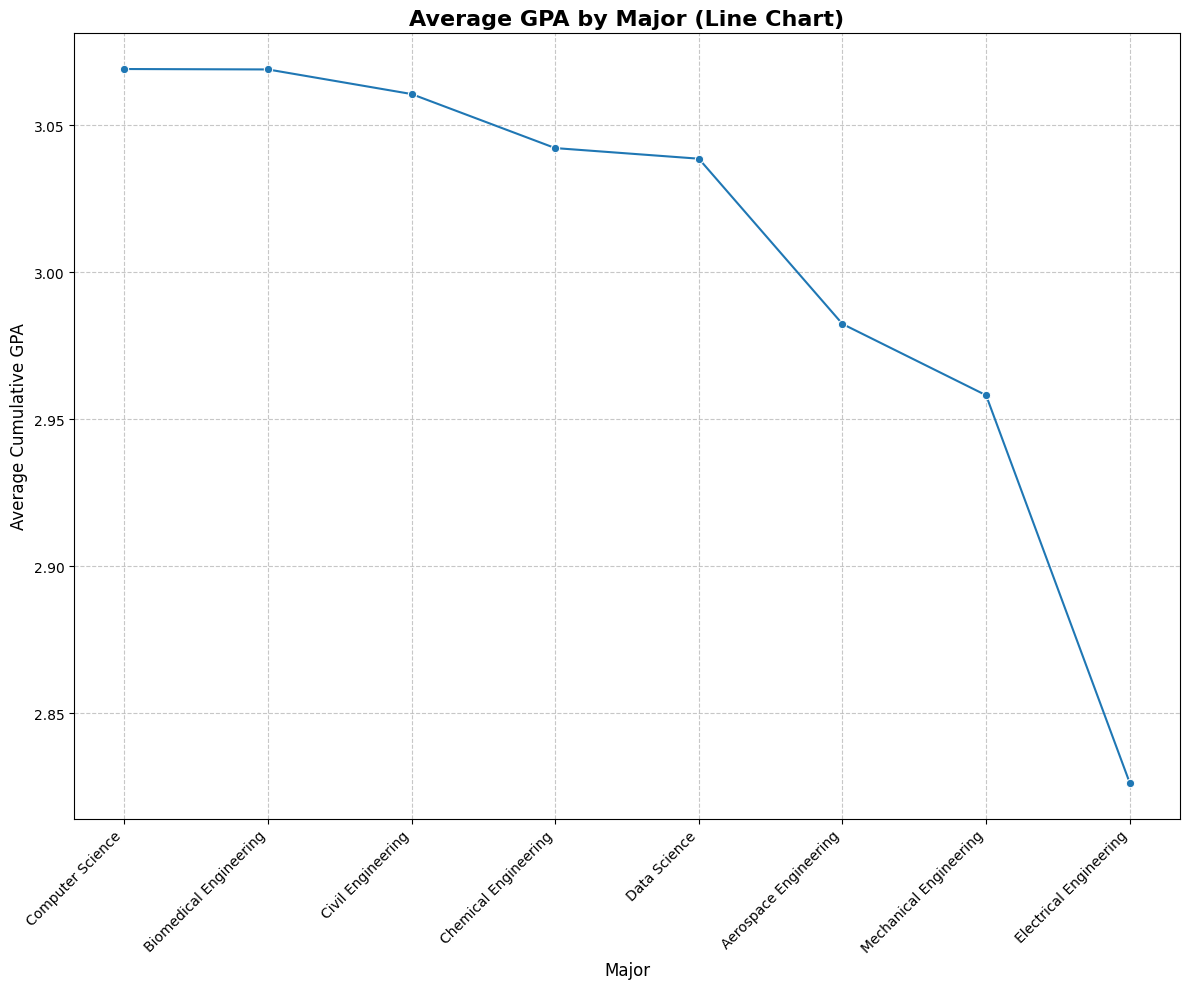

Finding: This line chart displays the average cumulative GPA for each major. CompSci and BioMed engineers generally have the highest average GPA, compared to MechE and EE.


In [ ]:
"""Calculate average GPA by major"""
avg_gpa_by_major = df.groupby('major')['cumulative_gpa'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 10))
sns.lineplot(data=avg_gpa_by_major, x='major', y='cumulative_gpa', marker='o') # Adds points at each data point
plt.title('Average GPA by Major (Line Chart)', fontsize=16, fontweight='bold')
plt.xlabel('Major', fontsize=12)
plt.ylabel('Average Cumulative GPA', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for better readability
plt.tight_layout()
plt.show()

print("Finding: This line chart displays the average cumulative GPA for each major. CompSci and BioMed engineers generally have the highest average GPA, compared to MechE and EE.")

In [ ]:
# Summary
print("Key takeaways: \nGPA has a heavy impact on student activities. \nFrom earlier, students who had a GPA of 3.5 or above generally participated in the most clubs. \nThe ratio of students that have or haven't participated in research in jobs or grad school is practically the same, with only the number of students in research that differs. \nDiffering engineering fields generally have different average GPAs, some being lower or higher than another.")

Key takeaways: 
GPA has a heavy impact on student activities. 
From earlier, students who had a GPA of 3.5 or above generally participated in the most clubs. 
The ratio of students that have or haven't participated in research in jobs or grad school is practically the same, with only the number of students in research that differs. 
Differing engineering fields generally have different average GPAs, some being lower or higher than another.
